# Nemotron 3 Nano 30B A3B: 128K disaggregated versus aggregated

A matched live test on the same 16 H200 GPUs, checkpoint, image and PVCs.
Each topology serves the same 32 three-turn sessions at concurrency 4: **96 requests
per run, 128,000–128,092 prompt tokens, up to 256 output tokens**.
The context window is 131,072 tokens. Non-thinking mode, temperature 0.

The CPU client runs inside the cluster and uses the same frontend ClusterIP.
Both worker KV caches are cleared before each run; follow-up turns can reuse
context. Model/kernel warmup pilots are excluded. Disaggregated runs first;
aggregated runs second. Three runs per topology fit the approximately 30-minute
measurement budget: **288 measured requests per topology**. This small sample
shows observed variation but does not establish reliable p99s or maximum capacity.

The final cluster is left **aggregated**. Raw measurements, metadata and worker
Prometheus snapshots are stored in `results/nemotron-3-nano-128k-comparison/`.
Run all cells using the repository `.venv` kernel. No load is generated here.

In [1]:
from pathlib import Path
import os, json, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
ROOT = Path.cwd() if (Path.cwd() / 'benchmarks').exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))
from benchmarks.collect import collect
RESULTS = Path(os.environ.get('NEMOTRON_128K_RESULTS', ROOT / 'results/nemotron-3-nano-128k-comparison'))
EXPORT = RESULTS / 'analysis'
EXPORT.mkdir(parents=True, exist_ok=True)
summary_path = collect(RESULTS)
runs = pd.read_csv(summary_path) if summary_path else pd.DataFrame()
LABELS = {'dynamo-disagg-k8s': 'Disaggregated (1P + 1D)', 'dynamo-agg-k8s': 'Aggregated (2 replicas)'}
ORDER = list(LABELS.values())
plt.style.use('seaborn-v0_8-whitegrid')
print(f'{len(runs)} runs from {RESULTS}')


6 runs -> /Users/behnam/workspace/serving-solutions/results/nemotron-3-nano-128k-comparison/summary.csv
6 runs from /Users/behnam/workspace/serving-solutions/results/nemotron-3-nano-128k-comparison


## Audit the experiment

Failures and invalid measurements must be visible before inspecting speed. Confirm
that the dataset, budgets, GPU count and sampling options match. Deployment hashes
must differ because the worker topology differs. The full deployment snapshots
are in each run's `metadata.json`.

In [2]:
requests = pd.DataFrame()
if not runs.empty:
    display(runs[['run_id','technology','requests','failed_requests','invalid_measurements',
                  'duration_s','concurrency','prompt_tokens_mean','completion_tokens_mean',
                  'dataset_sha256','cache_state','gpu_count']])
    for field in ['dataset_sha256','model','model_revision','image','gpu_count','concurrency',
                  'sessions','max_model_len','requested_output_tokens','min_input_tokens',
                  'extra_body_json','temperature','cache_state','session_rate','think_time_s']:
        assert runs[field].nunique(dropna=False) == 1, f'Mismatched setting: {field}'
    frames=[]
    for row in runs.itertuples():
        frame=pd.read_csv(RESULTS / row.run_id / 'requests.csv')
        frame['mode']=LABELS[row.technology]
        frame['run_id']=row.run_id
        frames.append(frame)
    requests=pd.concat(frames,ignore_index=True)
    display(requests.groupby('mode').agg(requests=('success','size'),
        successful=('success','sum'), valid=('measurement_valid','sum'),
        min_prompt=('prompt_tokens','min'), max_prompt=('prompt_tokens','max'),
        mean_output=('completion_tokens','mean')))
    if set(runs.technology) == set(LABELS):
        assert runs.groupby('technology').size().nunique() == 1, 'Different repeat counts'
        expected=None
        for run_id, frame in requests.groupby('run_id'):
            indexed=frame.set_index(['session_id','turn'])
            assert indexed.index.is_unique, 'Duplicate session/turn within a run'
            hashes=indexed.request_sha256.sort_index()
            if expected is None: expected=hashes
            else: assert expected.equals(hashes), f'Request bodies differ: {run_id}'
        print(f'Verified identical bodies for all {len(expected)} session/turn pairs across {len(runs)} runs.')
    else:
        print('Comparison incomplete: both topology runs are required.')


,run_id,technology,requests,failed_requests,invalid_measurements,duration_s,concurrency,prompt_tokens_mean,completion_tokens_mean,dataset_sha256,cache_state,gpu_count
0,20260930T233220Z-9a685726,dynamo-disagg-k8s,96,0,0,106.660469,4,128042.166667,177.552083,0b3eaee6efc900ffce4bba9262fe90906e7b1468b56546...,mixed,16
1,20260930T233410Z-7638e263,dynamo-disagg-k8s,96,0,0,104.531174,4,128042.166667,176.916667,0b3eaee6efc900ffce4bba9262fe90906e7b1468b56546...,mixed,16
2,20260930T233557Z-df8c0fda,dynamo-disagg-k8s,96,0,0,105.256710,4,128042.166667,176.843750,0b3eaee6efc900ffce4bba9262fe90906e7b1468b56546...,mixed,16
3,20260930T234109Z-195ac77a,dynamo-agg-k8s,96,0,0,68.381961,4,128042.166667,177.187500,0b3eaee6efc900ffce4bba9262fe90906e7b1468b56546...,mixed,16
4,20260930T234220Z-714521e9,dynamo-agg-k8s,96,0,0,63.202040,4,128042.166667,177.843750,0b3eaee6efc900ffce4bba9262fe90906e7b1468b56546...,mixed,16
5,20260930T234325Z-fffc898d,dynamo-agg-k8s,96,0,0,63.698436,4,128042.166667,178.343750,0b3eaee6efc900ffce4bba9262fe90906e7b1468b56546...,mixed,16


,requests,successful,valid,min_prompt,max_prompt,mean_output
mode,,,,,,
Aggregated (2 replicas),288,288,288,128000,128092,177.791667
Disaggregated (1P + 1D),288,288,288,128000,128092,177.104167


Verified identical bodies for all 96 session/turn pairs across 6 runs.


## Whole-run throughput and latency

Output throughput uses actual generated output tokens divided by wall time. The
256-token budget is a ceiling; early stopping and small numerical differences can
produce different output lengths. Report request throughput and output lengths
alongside token throughput. SGLang does not expose exact token-resolved ITL here;
TPOT is the average inter-token time within each response.

,mode,duration_s,requests,request_throughput_rps,output_throughput_tps,output_tps_per_gpu,ttft_p50_s,ttft_p95_s,tpot_ms_p50,tpot_ms_p95,completion_tokens_mean
0,Disaggregated (1P + 1D),106.660469,96,0.900052,159.806160,9.987885,2.447695,10.459462,4.586135,5.035597,177.552083
1,Disaggregated (1P + 1D),104.531174,96,0.918386,162.477846,10.154865,2.619980,10.133225,4.692396,5.133373,176.916667
2,Disaggregated (1P + 1D),105.256710,96,0.912056,161.291381,10.080711,2.440310,10.208491,4.629375,5.165573,176.843750
3,Aggregated (2 replicas),68.381961,96,1.403879,248.749811,15.546863,0.131765,5.364541,4.150361,14.789259,177.187500
4,Aggregated (2 replicas),63.202040,96,1.518938,270.133684,16.883355,0.102208,2.867568,4.417389,14.780873,177.843750
5,Aggregated (2 replicas),63.698436,96,1.507101,268.782110,16.798882,0.096856,2.961785,4.469937,14.960332,178.343750


duration_s                          \
                               mean         min         max   
mode                                                          
Disaggregated (1P + 1D)  105.482784  104.531174  106.660469   
Aggregated (2 replicas)   65.094146   63.202040   68.381961   

                        request_throughput_rps                      \
                                          mean       min       max   
mode                                                                 
Disaggregated (1P + 1D)               0.910165  0.900052  0.918386   
Aggregated (2 replicas)               1.476640  1.403879  1.518938   

                        output_throughput_tps                          \
                                         mean         min         max   
mode                                                                    
Disaggregated (1P + 1D)            161.191796  159.806160  162.477846   
Aggregated (2 replicas)            262.555202  248.749811  270.133684   

                        ttft_p50_s                     tpot_ms_p50            \
                              mean       min       max        mean       min   
mode                                                                           
Disaggregated (1P + 1D)   2.502662  2.440310  2.619980    4.635969  4.586135   
Aggregated (2 replicas)   0.110276  0.096856  0.131765    4.345896  4.150361   

                                   
                              max  
mode                               
Disaggregated (1P + 1D)  4.692396  
Aggregated (2 replicas)  4.469937

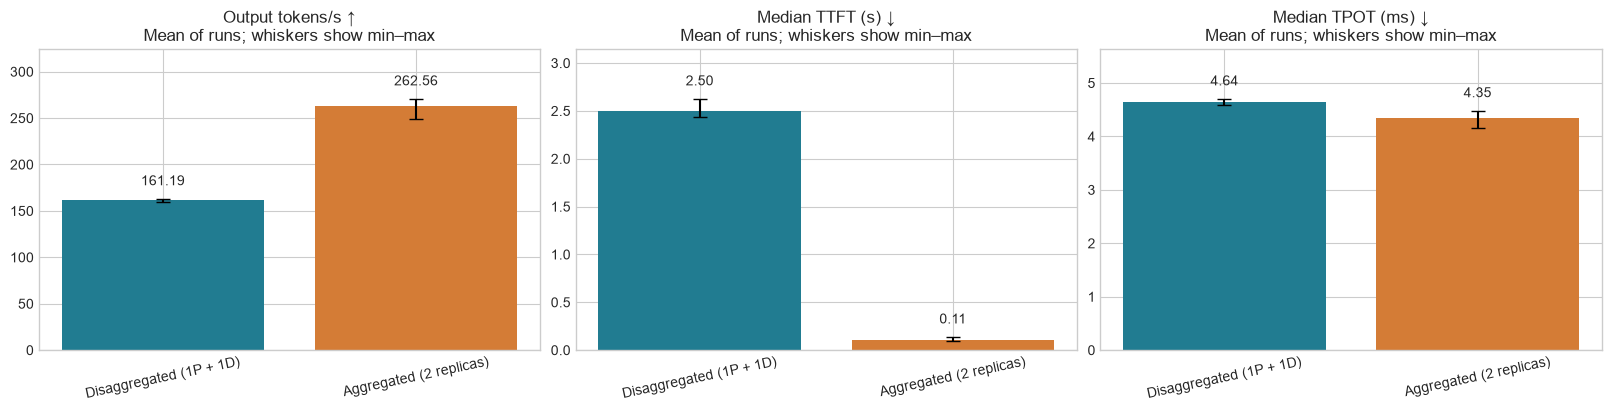

In [3]:
comparison=pd.DataFrame()
if not runs.empty:
    comparison=runs[(runs.failed_requests==0)&(runs.invalid_measurements==0)].copy()
    comparison['mode']=comparison.technology.map(LABELS)
    comparison['output_tps_per_gpu']=comparison.output_throughput_tps/comparison.gpu_count
    comparison['ttft_p50_s']=comparison.ttft_ms_p50/1000
    comparison['ttft_p95_s']=comparison.ttft_ms_p95/1000
    display(comparison[['mode','duration_s','requests','request_throughput_rps',
        'output_throughput_tps','output_tps_per_gpu','ttft_p50_s','ttft_p95_s',
        'tpot_ms_p50','tpot_ms_p95','completion_tokens_mean']])
    comparison.to_csv(EXPORT/'topology-comparison.csv',index=False)
    if not comparison.empty:
        metrics=['duration_s','request_throughput_rps','output_throughput_tps','ttft_p50_s','tpot_ms_p50']
        aggregate=comparison.groupby('mode')[metrics].agg(['mean','min','max']).reindex(ORDER)
        display(aggregate)
        aggregate.to_csv(EXPORT/'topology-aggregate.csv')
        fig,axes=plt.subplots(1,3,figsize=(16,4),layout='constrained')
        for ax,col,title in zip(axes,['output_throughput_tps','ttft_p50_s','tpot_ms_p50'],
            ['Output tokens/s ↑','Median TTFT (s) ↓','Median TPOT (ms) ↓']):
            stat=aggregate[col]
            errors=np.vstack([stat['mean']-stat['min'],stat['max']-stat['mean']])
            bars=ax.bar(ORDER,stat['mean'],yerr=errors,capsize=5,color=['#217c91','#d47c36'])
            ax.bar_label(bars,fmt='%.2f',padding=8); ax.margins(y=.2)
            ax.set_title(title+'\nMean of runs; whiskers show min–max')
            ax.tick_params(axis='x',labelrotation=12)
        fig.savefig(EXPORT/'topology-comparison.png',dpi=180,bbox_inches='tight')
        plt.show()


## First turns versus context reuse

First turns begin after a cache reset and have unique session prefixes; later turns
can reuse their session context. Actual cache hits and eviction still depend on
the topology and scheduler. Separating these phases avoids hiding long-prefill
latency behind fast follow-up requests. The phase distributions pool requests from all three runs per topology.
TTFT includes queueing inside the serving stack; client concurrency-slot wait is recorded separately.

,mode,phase,requests,ttft_p50_s,ttft_p95_s,e2e_p50_s,tpot_p50_ms,mean_cached_tokens,mean_output_tokens
0,Aggregated (2 replicas),First turn,96,2.814454,5.421549,6.316624,4.467800,NaN,253.395833
1,Aggregated (2 replicas),Follow-up,192,0.092561,0.169762,1.074896,4.170205,128021.542105,139.989583
2,Disaggregated (1P + 1D),First turn,96,6.733859,10.587157,7.900103,4.580830,NaN,252.510417
3,Disaggregated (1P + 1D),Follow-up,192,0.257438,7.519745,1.443885,4.654317,128021.500000,139.401042


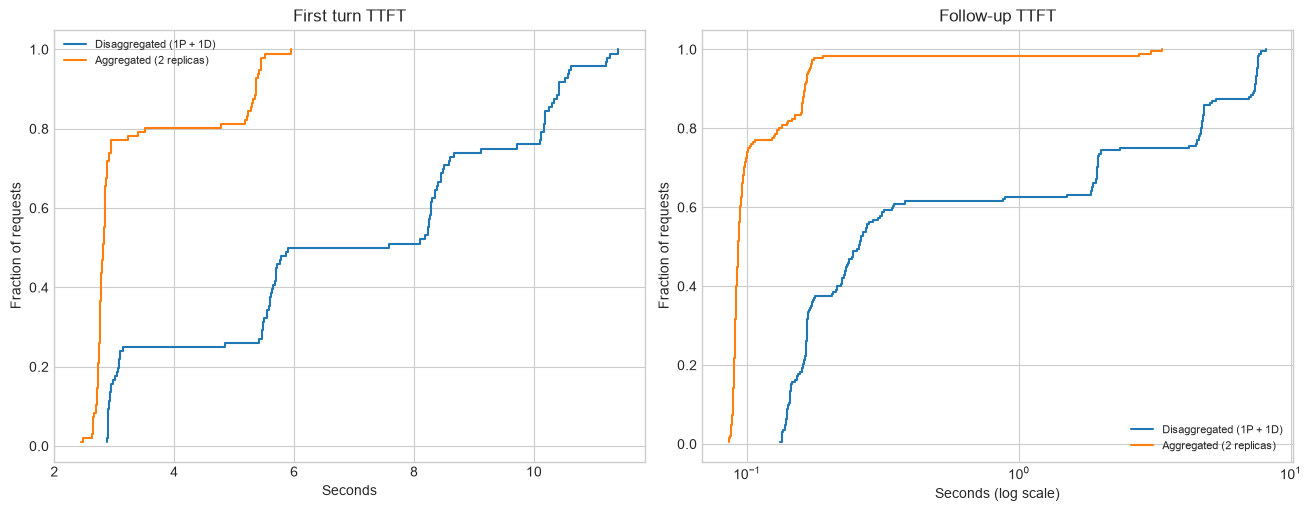

In [4]:
if not requests.empty:
    good=requests[(requests.success==True)&(requests.measurement_valid==True)].copy()
    good['phase']=np.where(good.turn==0,'First turn','Follow-up')
    good['ttft_s']=good.ttft_ms/1000
    good['e2e_s']=good.e2e_ms/1000
    phase=good.groupby(['mode','phase']).agg(
        requests=('turn','size'), ttft_p50_s=('ttft_s','median'),
        ttft_p95_s=('ttft_s',lambda x:x.quantile(.95)),
        e2e_p50_s=('e2e_s','median'), tpot_p50_ms=('tpot_ms','median'),
        mean_cached_tokens=('cached_tokens','mean'), mean_output_tokens=('completion_tokens','mean')).reset_index()
    display(phase)
    phase.to_csv(EXPORT/'latency-by-phase.csv',index=False)
    fig,axes=plt.subplots(1,2,figsize=(13,5),layout='constrained')
    for ax,phase_name in zip(axes,['First turn','Follow-up']):
        for mode in ORDER:
            values=np.sort(good.loc[(good['mode']==mode)&(good.phase==phase_name),'ttft_s'].dropna())
            if len(values):ax.step(values,np.arange(1,len(values)+1)/len(values),where='post',label=mode)
        ax.set_title(phase_name+' TTFT');ax.set_xlabel('Seconds');ax.set_ylabel('Fraction of requests');ax.legend(fontsize=8)
    axes[1].set_xscale('log'); axes[1].set_xlabel('Seconds (log scale)')
    fig.savefig(EXPORT/'ttft-by-phase.png',dpi=180,bbox_inches='tight')
    plt.show()
    good.to_csv(EXPORT/'valid-requests.csv',index=False)


## Interpretation and limits

- This compares **one TP8 prefill + one TP8 decode** against **two TP8 aggregated
  replicas**, with all 16 GPUs allocated in either case. Each worker admits four
  requests; the client caps total simultaneous sessions at four. TP8 is retained
  for comparison with the previous exercise, not selected as optimal for Nano.
- BF16 weights and native KV dtype are used. Both modes use the same explicit
  Mamba no-buffer cache settings and disable overlap scheduling; this is not
  a comparison of individually optimized serving configurations.
- Synthetic operations/policy conversations are replayed; answers and tool quality
  are not scored. Output lengths are not forced to be identical.
- Cache-reset acknowledgements, image/model manifests, raw streaming events and
  metrics snapshots accompany the results. Cached input throughput is not fresh
  prefill throughput.
- Three runs per topology show only a small sample of run-to-run variation.
  Fixed topology order leaves temporal effects unresolved. This is a measured workload comparison, not a
  general claim that either topology is faster for every workload.
- The 128K pilots are stored separately and excluded from the charts.

Exports are saved in the result folder's `analysis/` directory.